In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import easyocr
import re
from collections import defaultdict, deque

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\Amitkumar\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

# import finetuned yolo model and ocr model

In [2]:
model = YOLO(r"C:\Users\cl502_19\Downloads\DL_ANPR\detection\license_plate_best.pt")
reader = easyocr.Reader(['en'], gpu = True)

In [4]:
plate_pattern = re.compile(r"^[A-Z]{2}[0-9]{2}[A-Z]{3}$")

# Mapping to closest num or alpha

In [5]:
# Number/Alpha correction maps
def correct_plate_format(ocr_text):
    mapping_num_to_alpha = {'0': 'O', '1': 'I', '2': 'Z', '5': 'S', '8': 'B'}
    mapping_alpha_to_num = {'O': '0', 'I': '1', 'Z': '2', 'S': '5', 'B': '8'}

    ocr_text = ocr_text.upper().replace(" ", "")
    if len(ocr_text) != 7:
        return ""  # discard if wrong length

    corrected = []
    for i, ch in enumerate(ocr_text):
        if i < 2 or i > 4:  # alphabet positions
            if ch.isdigit() and ch in mapping_num_to_alpha:
                corrected.append(mapping_num_to_alpha[ch])
            elif ch.isalpha():
                corrected.append(ch)
            else:
                return ""  # invalid char
        else:  # numeric positions
            if ch.isalpha() and ch in mapping_alpha_to_num:
                corrected.append(mapping_alpha_to_num[ch])
            elif ch.isdigit():
                corrected.append(ch)
            else:
                return ""  # invalid char
    return "".join(corrected)

# Preprocessing the license plate region before ocr

In [6]:
def recognize_plate(plate_crop):
    if plate_crop.size == 0:
        return ""

    # Preprocess for OCR
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    plate_resized = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    try:
        ocr_result = reader.readtext(
            plate_resized, detail=0, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        )
        if len(ocr_result) > 0:
            candidate = correct_plate_format(ocr_result[0])
            if candidate and plate_pattern.match(candidate):
                return candidate
    except:
        pass

    return ""


# Number plate stabalization buffer

In [7]:
plate_history = defaultdict(lambda: deque(maxlen=10))  # last 10 predictions per box
plate_final = {}

def get_box_id(x1, y1, x2, y2):
    # Use rounded coordinates as a pseudo ID
    return f"{int(x1/10)}_{int(y1/10)}_{int(x2/10)}_{int(y2/10)}"

def get_stable_plate(box_id, new_text):
    if new_text:
        plate_history[box_id].append(new_text)
        # Majority vote
        most_common = max(set(plate_history[box_id]), key=plate_history[box_id].count)
        plate_final[box_id] = most_common
    return plate_final.get(box_id, "")


# Video for inferenceing 

In [9]:
input_video = r"C:\Users\cl502_19\Downloads\DL_ANPR\detection\sample video\VID_20251102_150632428.mp4"
output_video = "output_with_licensev3.mp4"

cap = cv2.VideoCapture(input_video)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc,
    cap.get(cv2.CAP_PROP_FPS),
    (int(cap.get(3)), int(cap.get(4))))

CONF_THRESH = 0.3


# operating frame by frame 

In [11]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.ion()  # enable interactive mode for live display in notebook

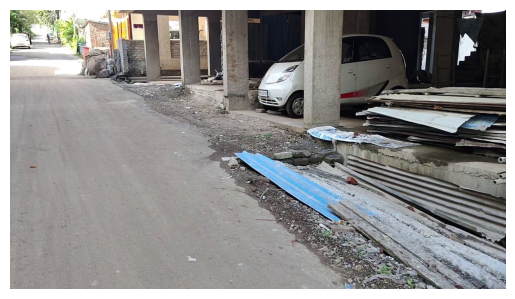

In [12]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            conf = float(box.conf.cpu().numpy())
            if conf < CONF_THRESH:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy.cpu().numpy()[0])
            plate_crop = frame[y1:y2, x1:x2]

            # OCR with correction
            text = recognize_plate(plate_crop)

            # Stabilize text using history
            box_id = get_box_id(x1, y1, x2, y2)
            stable_text = get_stable_plate(box_id, text)

            # Draw simple rectangle around license plate
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 3)

            # Overlay zoomed-in plate above detected plate
            if plate_crop.size > 0:
                overlay_h, overlay_w = 150, 400
                plate_resized = cv2.resize(plate_crop, (overlay_w, overlay_h))

                oy1 = max(0, y1 - overlay_h - 40)
                ox1 = x1
                oy2, ox2 = oy1 + overlay_h, ox1 + overlay_w

                if oy2 <= frame.shape[0] and ox2 <= frame.shape[1]:
                    frame[oy1:oy2, ox1:ox2] = plate_resized

                    # Show stabilized OCR text above overlay
            if stable_text:
                cv2.putText(frame, stable_text, (ox1, oy1 - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 6)  # black outline
                cv2.putText(frame, stable_text, (ox1, oy1 - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 3)  # white text
                
    # out.write(frame)
    # cv2.imshow("Annotated Video", frame)
    # if cv2.waitKey(1) & 0xFF == ord('q'):
    # break
    
        out.write(frame)
        clear_output(wait=True)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

  

# close all 

In [13]:
cap.release()
out.release()
# cv2.destroyAllWindows()
plt.ioff()     # turn off interactive mode
plt.close()    # close last frame display

plt.ioff()     # turn off interactive mode
plt.close()    # close last frame display

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
import easyocr
import re
from collections import defaultdict, deque

model = YOLO(r"C:\Users\cl502_19\Downloads\DL_ANPR\detection\license_plate_best.pt")
reader = easyocr.Reader(['en'], gpu = True)

plate_pattern = re.compile(r"^[A-Z]{2}[0-9]{2}[A-Z]{3}$")


# Number/Alpha correction maps
def correct_plate_format(ocr_text):
    mapping_num_to_alpha = {'0': 'O', '1': 'I', '2': 'Z', '5': 'S', '8': 'B'}
    mapping_alpha_to_num = {'O': '0', 'I': '1', 'Z': '2', 'S': '5', 'B': '8'}

    ocr_text = ocr_text.upper().replace(" ", "")
    if len(ocr_text) != 7:
        return ""  # discard if wrong length

    corrected = []
    for i, ch in enumerate(ocr_text):
        if i < 2 or i > 4:  # alphabet positions
            if ch.isdigit() and ch in mapping_num_to_alpha:
                corrected.append(mapping_num_to_alpha[ch])
            elif ch.isalpha():
                corrected.append(ch)
            else:
                return ""  # invalid char
        else:  # numeric positions
            if ch.isalpha() and ch in mapping_alpha_to_num:
                corrected.append(mapping_alpha_to_num[ch])
            elif ch.isdigit():
                corrected.append(ch)
            else:
                return ""  # invalid char
    return "".join(corrected)


def recognize_plate(plate_crop):
    if plate_crop.size == 0:
        return ""

    # Preprocess for OCR
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    plate_resized = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    try:
        ocr_result = reader.readtext(
            plate_resized, detail=0, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        )
        if len(ocr_result) > 0:
            candidate = correct_plate_format(ocr_result[0])
            if candidate and plate_pattern.match(candidate):
                return candidate
    except:
        pass

    return ""

plate_history = defaultdict(lambda: deque(maxlen=10))  # last 10 predictions per box
plate_final = {}

def get_box_id(x1, y1, x2, y2):
    # Use rounded coordinates as a pseudo ID
    return f"{int(x1/10)}_{int(y1/10)}_{int(x2/10)}_{int(y2/10)}"

def get_stable_plate(box_id, new_text):
    if new_text:
        plate_history[box_id].append(new_text)
        # Majority vote
        most_common = max(set(plate_history[box_id]), key=plate_history[box_id].count)
        plate_final[box_id] = most_common
    return plate_final.get(box_id, "")

input_video = r"C:\Users\cl502_19\Downloads\DL_ANPR\detection\sample video\VID_20251102_150632428.mp4"
output_video = "output_with_licensev3.mp4"

cap = cv2.VideoCapture(input_video)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc,
    cap.get(cv2.CAP_PROP_FPS),
    (int(cap.get(3)), int(cap.get(4))))

CONF_THRESH = 0.3


import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.ion()  # enable interactive mode for live display in notebook

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            conf = float(box.conf.cpu().numpy())
            if conf < CONF_THRESH:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy.cpu().numpy()[0])
            plate_crop = frame[y1:y2, x1:x2]

            # OCR with correction
            text = recognize_plate(plate_crop)

            # Stabilize text using history
            box_id = get_box_id(x1, y1, x2, y2)
            stable_text = get_stable_plate(box_id, text)

            # Draw simple rectangle around license plate
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 3)

            # Overlay zoomed-in plate above detected plate
            if plate_crop.size > 0:
                overlay_h, overlay_w = 150, 400
                plate_resized = cv2.resize(plate_crop, (overlay_w, overlay_h))

                oy1 = max(0, y1 - overlay_h - 40)
                ox1 = x1
                oy2, ox2 = oy1 + overlay_h, ox1 + overlay_w

                if oy2 <= frame.shape[0] and ox2 <= frame.shape[1]:
                    frame[oy1:oy2, ox1:ox2] = plate_resized

                    # Show stabilized OCR text above overlay
            if stable_text:
                cv2.putText(frame, stable_text, (ox1, oy1 - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 6)  # black outline
                cv2.putText(frame, stable_text, (ox1, oy1 - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 3)  # white text
                
    # out.write(frame)
    # cv2.imshow("Annotated Video", frame)
    # if cv2.waitKey(1) & 0xFF == ord('q'):
    # break
    
        out.write(frame)
        clear_output(wait=True)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

  
cap.release()
out.release()
# cv2.destroyAllWindows()
plt.ioff()     # turn off interactive mode
plt.close()    # close last frame display

plt.ioff()     # turn off interactive mode
plt.close()    # close last frame display

# testing new video


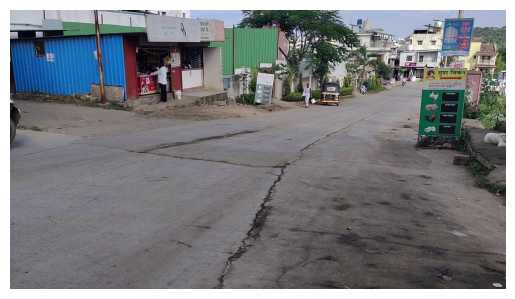

✅ Finished processing new video. Saved as output_with_license_test2.mp4


In [15]:
# =============================
# 🔁 Re-run detection on a new video
# =============================

# Define a new input video path for testing
new_video_path = r"C:\Users\cl502_19\Downloads\DL_ANPR\detection\sample video\VID_20251102_151020839.mp4"
new_output_path = "output_with_license_test2.mp4"

# Re-initialize video capture and writer
cap = cv2.VideoCapture(new_video_path)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(
    new_output_path, fourcc,
    cap.get(cv2.CAP_PROP_FPS),
    (int(cap.get(3)), int(cap.get(4)))
)

plt.ion()  # enable live display
CONF_THRESH = 0.3

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            conf = float(box.conf.cpu().numpy())
            if conf < CONF_THRESH:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy.cpu().numpy()[0])
            plate_crop = frame[y1:y2, x1:x2]

            text = recognize_plate(plate_crop)
            box_id = get_box_id(x1, y1, x2, y2)
            stable_text = get_stable_plate(box_id, text)

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 3)

            if plate_crop.size > 0:
                overlay_h, overlay_w = 150, 400
                plate_resized = cv2.resize(plate_crop, (overlay_w, overlay_h))

                oy1 = max(0, y1 - overlay_h - 40)
                ox1 = x1
                oy2, ox2 = oy1 + overlay_h, ox1 + overlay_w

                if oy2 <= frame.shape[0] and ox2 <= frame.shape[1]:
                    frame[oy1:oy2, ox1:ox2] = plate_resized

            if stable_text:
                cv2.putText(frame, stable_text, (x1, max(0, y1 - 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 6)
                cv2.putText(frame, stable_text, (x1, max(0, y1 - 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 3)

    out.write(frame)
    clear_output(wait=True)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

cap.release()
out.release()
plt.ioff()
plt.close()

print(f"✅ Finished processing new video. Saved as {new_output_path}")


In [16]:
# end 

# DROIDCAM 



In [ ]:
import cv2
import datetime
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Your existing detection and OCR functions
# from your_module import model, recognize_plate, get_box_id, get_stable_plate

# --- Connect to DroidCam ---
# Use the IP and port from DroidCam app
# For example: http://100.87.169.196:4747/video
DROIDCAM_URL = "http://100.87.169.196:4747/video"
cap = cv2.VideoCapture(DROIDCAM_URL)

# Optional: set resolution if DroidCam supports it
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

CONF_THRESH = 0.5

# Open a log file to store recognized plates
log_file = open("plate_log.txt", "a")

# Video writer (optional)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output.mp4', fourcc, 20.0, (1280, 720))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("⚠️ Unable to read frame from DroidCam.")
        break

    results = model(frame, verbose=False)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            conf = float(box.conf.cpu().numpy())
            if conf < CONF_THRESH:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy.cpu().numpy()[0])
            plate_crop = frame[y1:y2, x1:x2]

            # OCR with correction
            text = recognize_plate(plate_crop)

            # Stabilize text using history
            box_id = get_box_id(x1, y1, x2, y2)
            stable_text = get_stable_plate(box_id, text)

            # Draw simple rectangle around license plate
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 3)

            # Overlay zoomed-in plate above detected plate
            if plate_crop.size > 0:
                overlay_h, overlay_w = 150, 400
                plate_resized = cv2.resize(plate_crop, (overlay_w, overlay_h))

                oy1 = max(0, y1 - overlay_h - 40)
                ox1 = x1
                oy2, ox2 = oy1 + overlay_h, ox1 + overlay_w

                if oy2 <= frame.shape[0] and ox2 <= frame.shape[1]:
                    frame[oy1:oy2, ox1:ox2] = plate_resized

            # Display stabilized OCR text
            if stable_text:
                cv2.putText(frame, stable_text, (ox1, oy1 - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 6)
                cv2.putText(frame, stable_text, (ox1, oy1 - 20),
                            cv2.FONT_HERSHEY_SIMPLEX, 2, (255,255,255), 3)

                # Log recognized plate with timestamp
                log_entry = f"{stable_text}, {datetime.datetime.now()}\n"
                log_file.write(log_entry)
                log_file.flush()

    # Write to output file
    out.write(frame)

    # Show the live video
    clear_output(wait=True)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Cleanup
cap.release()
out.release()
log_file.close()
cv2.destroyAllWindows()
